In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile

zip_path = "tomato.zip"  # Update this path as needed
extract_path = "/content/tomato_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [6]:
import os

print(os.listdir("/content/tomato_dataset/Tomato_Leaf_Dataset"))

['Tomato_Healthy', 'Tomato_Early_blight', 'Tomato_leaf_yellow_curl_virus', 'Tomato_leaf_late_blight', 'Tomato_septora_leaf_spot', 'Tomato_mold_leaf']


In [7]:
import os

dataset_path = "/content/tomato_dataset/Tomato_Leaf_Dataset"

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)))

Tomato_Healthy : 1200
Tomato_Early_blight : 1200
Tomato_leaf_yellow_curl_virus : 1200
Tomato_leaf_late_blight : 1200
Tomato_septora_leaf_spot : 1200
Tomato_mold_leaf : 1200


Image size: (256, 256)


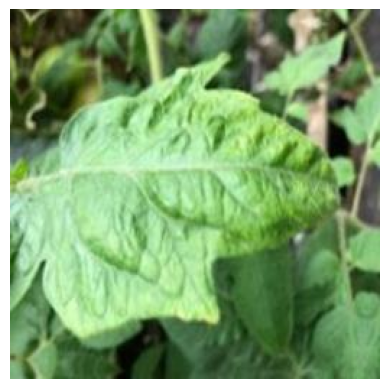

In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import os

dataset_path = "/content/tomato_dataset/Tomato_Leaf_Dataset"

class_name = "Tomato_Healthy"

image_name = os.listdir(os.path.join(dataset_path, class_name))[0]

image_path = os.path.join(dataset_path, class_name, image_name)

img = Image.open(image_path)

print("Image size:", img.size)

plt.imshow(img)
plt.axis("off")
plt.show()

In [9]:
import tensorflow as tf

dataset_path = "/content/tomato_dataset/Tomato_Leaf_Dataset"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

Found 7200 files belonging to 6 classes.
Using 5760 files for training.
Found 7200 files belonging to 6 classes.
Using 1440 files for validation.


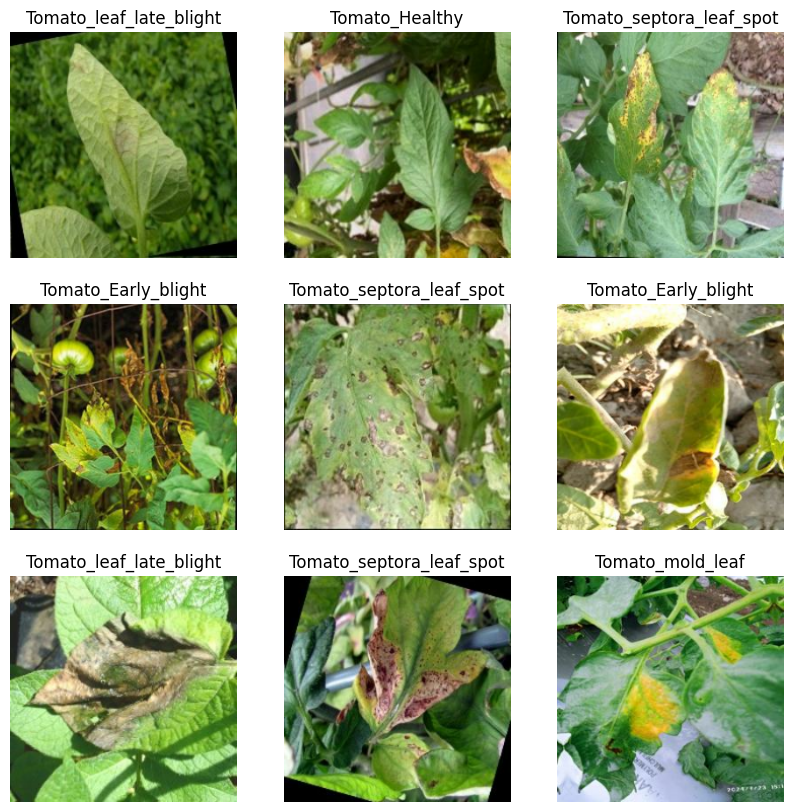

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(6, activation="softmax")
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 404s 2s/step - accuracy: 0.5052 - loss: 1.3225 - val_accuracy: 0.5562 - val_loss: 1.1822
Epoch 2/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.6288 - loss: 1.0344 - val_accuracy: 0.6528 - val_loss: 1.0082
Epoch 3/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - accuracy: 0.6837 - loss: 0.9078 - val_accuracy: 0.6715 - val_loss: 0.9412
Epoch 4/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 386s 2s/step - accuracy: 0.7108 - loss: 0.8348 - val_accuracy: 0.6417 - val_loss: 0.9644
Epoch 5/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.7278 - loss: 0.7677 - val_accuracy: 0.7146 - val_loss: 0.8617


In [13]:
model.save("/content/drive/MyDrive/tomato_leaf_model.h5")

In [14]:
import numpy as np
from tensorflow.keras.preprocessing import image
import os

# pick one image from the dataset
img_path = os.path.join(
    dataset_path,
    "Tomato_Healthy",
    os.listdir(os.path.join(dataset_path, "Tomato_Healthy"))[0]
)

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: Tomato_Healthy


In [ ]:
!pip install gradio

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_disease(img):

    img = img.resize((224, 224))

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(prediction)]

    return predicted_class

In [ ]:
  import gradio as gr

interface = gr.Interface(
    fn=predict_disease,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Tomato Leaf Disease Predictor",
    description="Upload a tomato leaf image to predict the disease."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://411a4b2e77732f847b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
